#### Visualização dos Dados utilizando as bibliotecas Seaborn e MatplotLib

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
df = pd.read_csv('marketing_AB.csv', index_col=0)
taxa_de_conversao = df.groupby('test group')['converted'].mean()
conversoes = df.groupby('test group')['converted'].sum()
diferenca_taxa = taxa_de_conversao['ad'] - taxa_de_conversao['psa']
registros = df.groupby('test group')['converted'].count()
registros_com_propaganda = registros['ad']
registros_sem_propaganda = registros['psa']
ganho_incremental  = registros_com_propaganda * diferenca_taxa
conversao_organica = registros_com_propaganda * taxa_de_conversao['psa']

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

grupos = ["Com propaganda", "Sem propaganda"]
taxas = [taxa_de_conversao["ad"], taxa_de_conversao["psa"]]

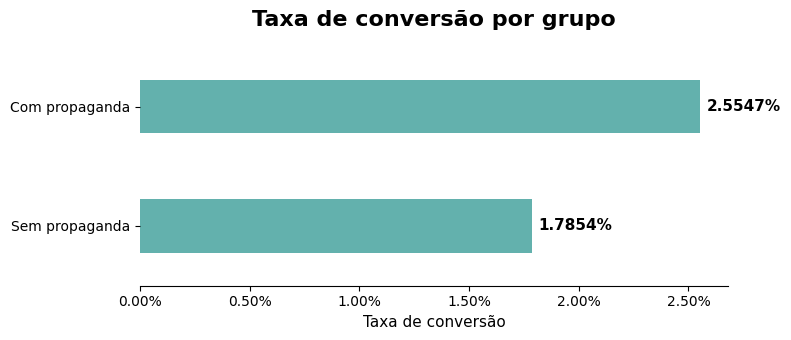

In [11]:

from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(8, 3.5))

ax = sns.barplot(
    x=taxas,
    y=grupos,
    color="#56BEB9",
    width=0.45
)

ax.xaxis.set_major_formatter(PercentFormatter(1))

ax.set_title(
    "Taxa de conversão por grupo",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Taxa de conversão", fontsize=11)
ax.set_ylabel("")


for i, taxa in enumerate(taxas):
    ax.text(
        taxa + 0.0003,
        i,
        f"{taxa:.4%}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

In [12]:
conversoes_grafico = [
    conversao_organica,
    ganho_incremental
]

categorias = [
    "Esperadas sem campanha",
    "Incrementais"
]

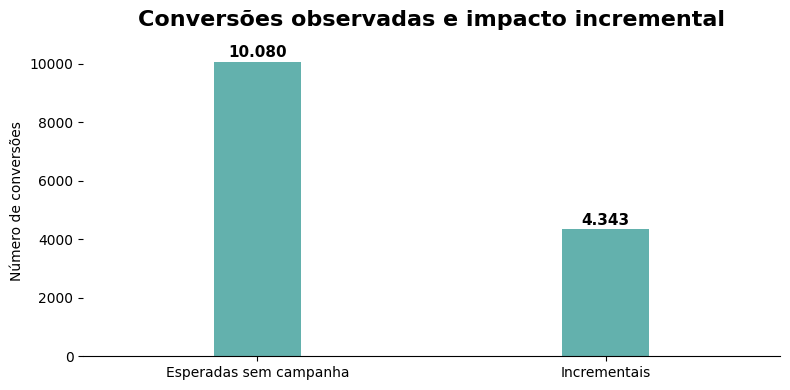

In [16]:
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    x=categorias,
    y=conversoes_grafico,
    color="#56BEB9",
    width=0.25
)

ax.set_title(
    "Conversões observadas e impacto incremental",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Número de conversões")
ax.set_xlabel("")

for i, valor in enumerate(conversoes_grafico):
    ax.text(
        i,
        valor + 150,
        f"{valor:,.0f}".replace(",", "."),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

Percentagem Orgânica: 69.888%
Percentagem Incremental: 30.112%


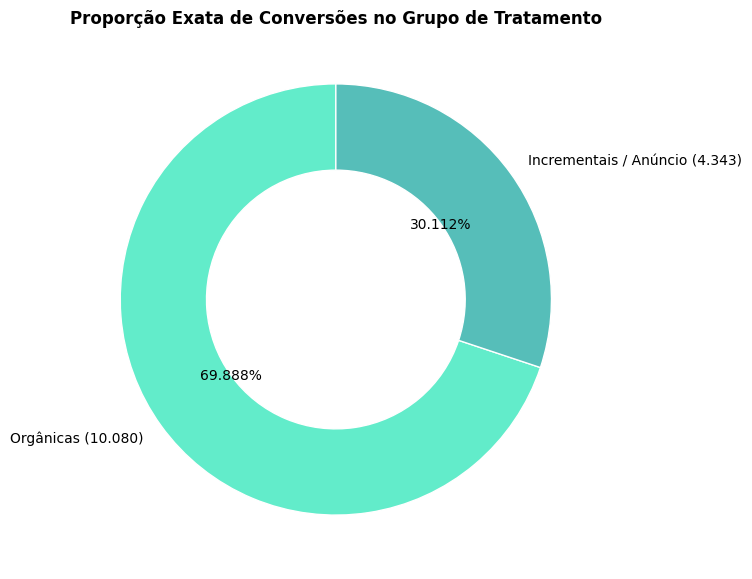

In [35]:

total_conversoes = conversao_organica + ganho_incremental
perc_organica = (conversao_organica / total_conversoes) * 100
perc_incremental = (ganho_incremental / total_conversoes) * 100

print(f"Percentagem Orgânica: {perc_organica:.3f}%")
print(f"Percentagem Incremental: {perc_incremental:.3f}%")


tamanhos = [conversao_organica, ganho_incremental]
labels = [
    f"Orgânicas {(f'({conversao_organica:,.0f})').replace(',', '.')}",
    f"Incrementais / Anúncio {(f'({ganho_incremental:,.0f})').replace(',', '.')}"
]
cores = ["#62ecca", '#56BEB9']

plt.figure(figsize=(7, 7))
plt.pie(
    tamanhos, 
    labels=labels, 
    colors=cores, 
    autopct='%1.3f%%', 
    startangle=90, 
    wedgeprops=dict(width=0.4, edgecolor='w')
)

plt.title('Proporção Exata de Conversões no Grupo de Tratamento', fontsize=12, fontweight='bold', pad=5)
plt.show()